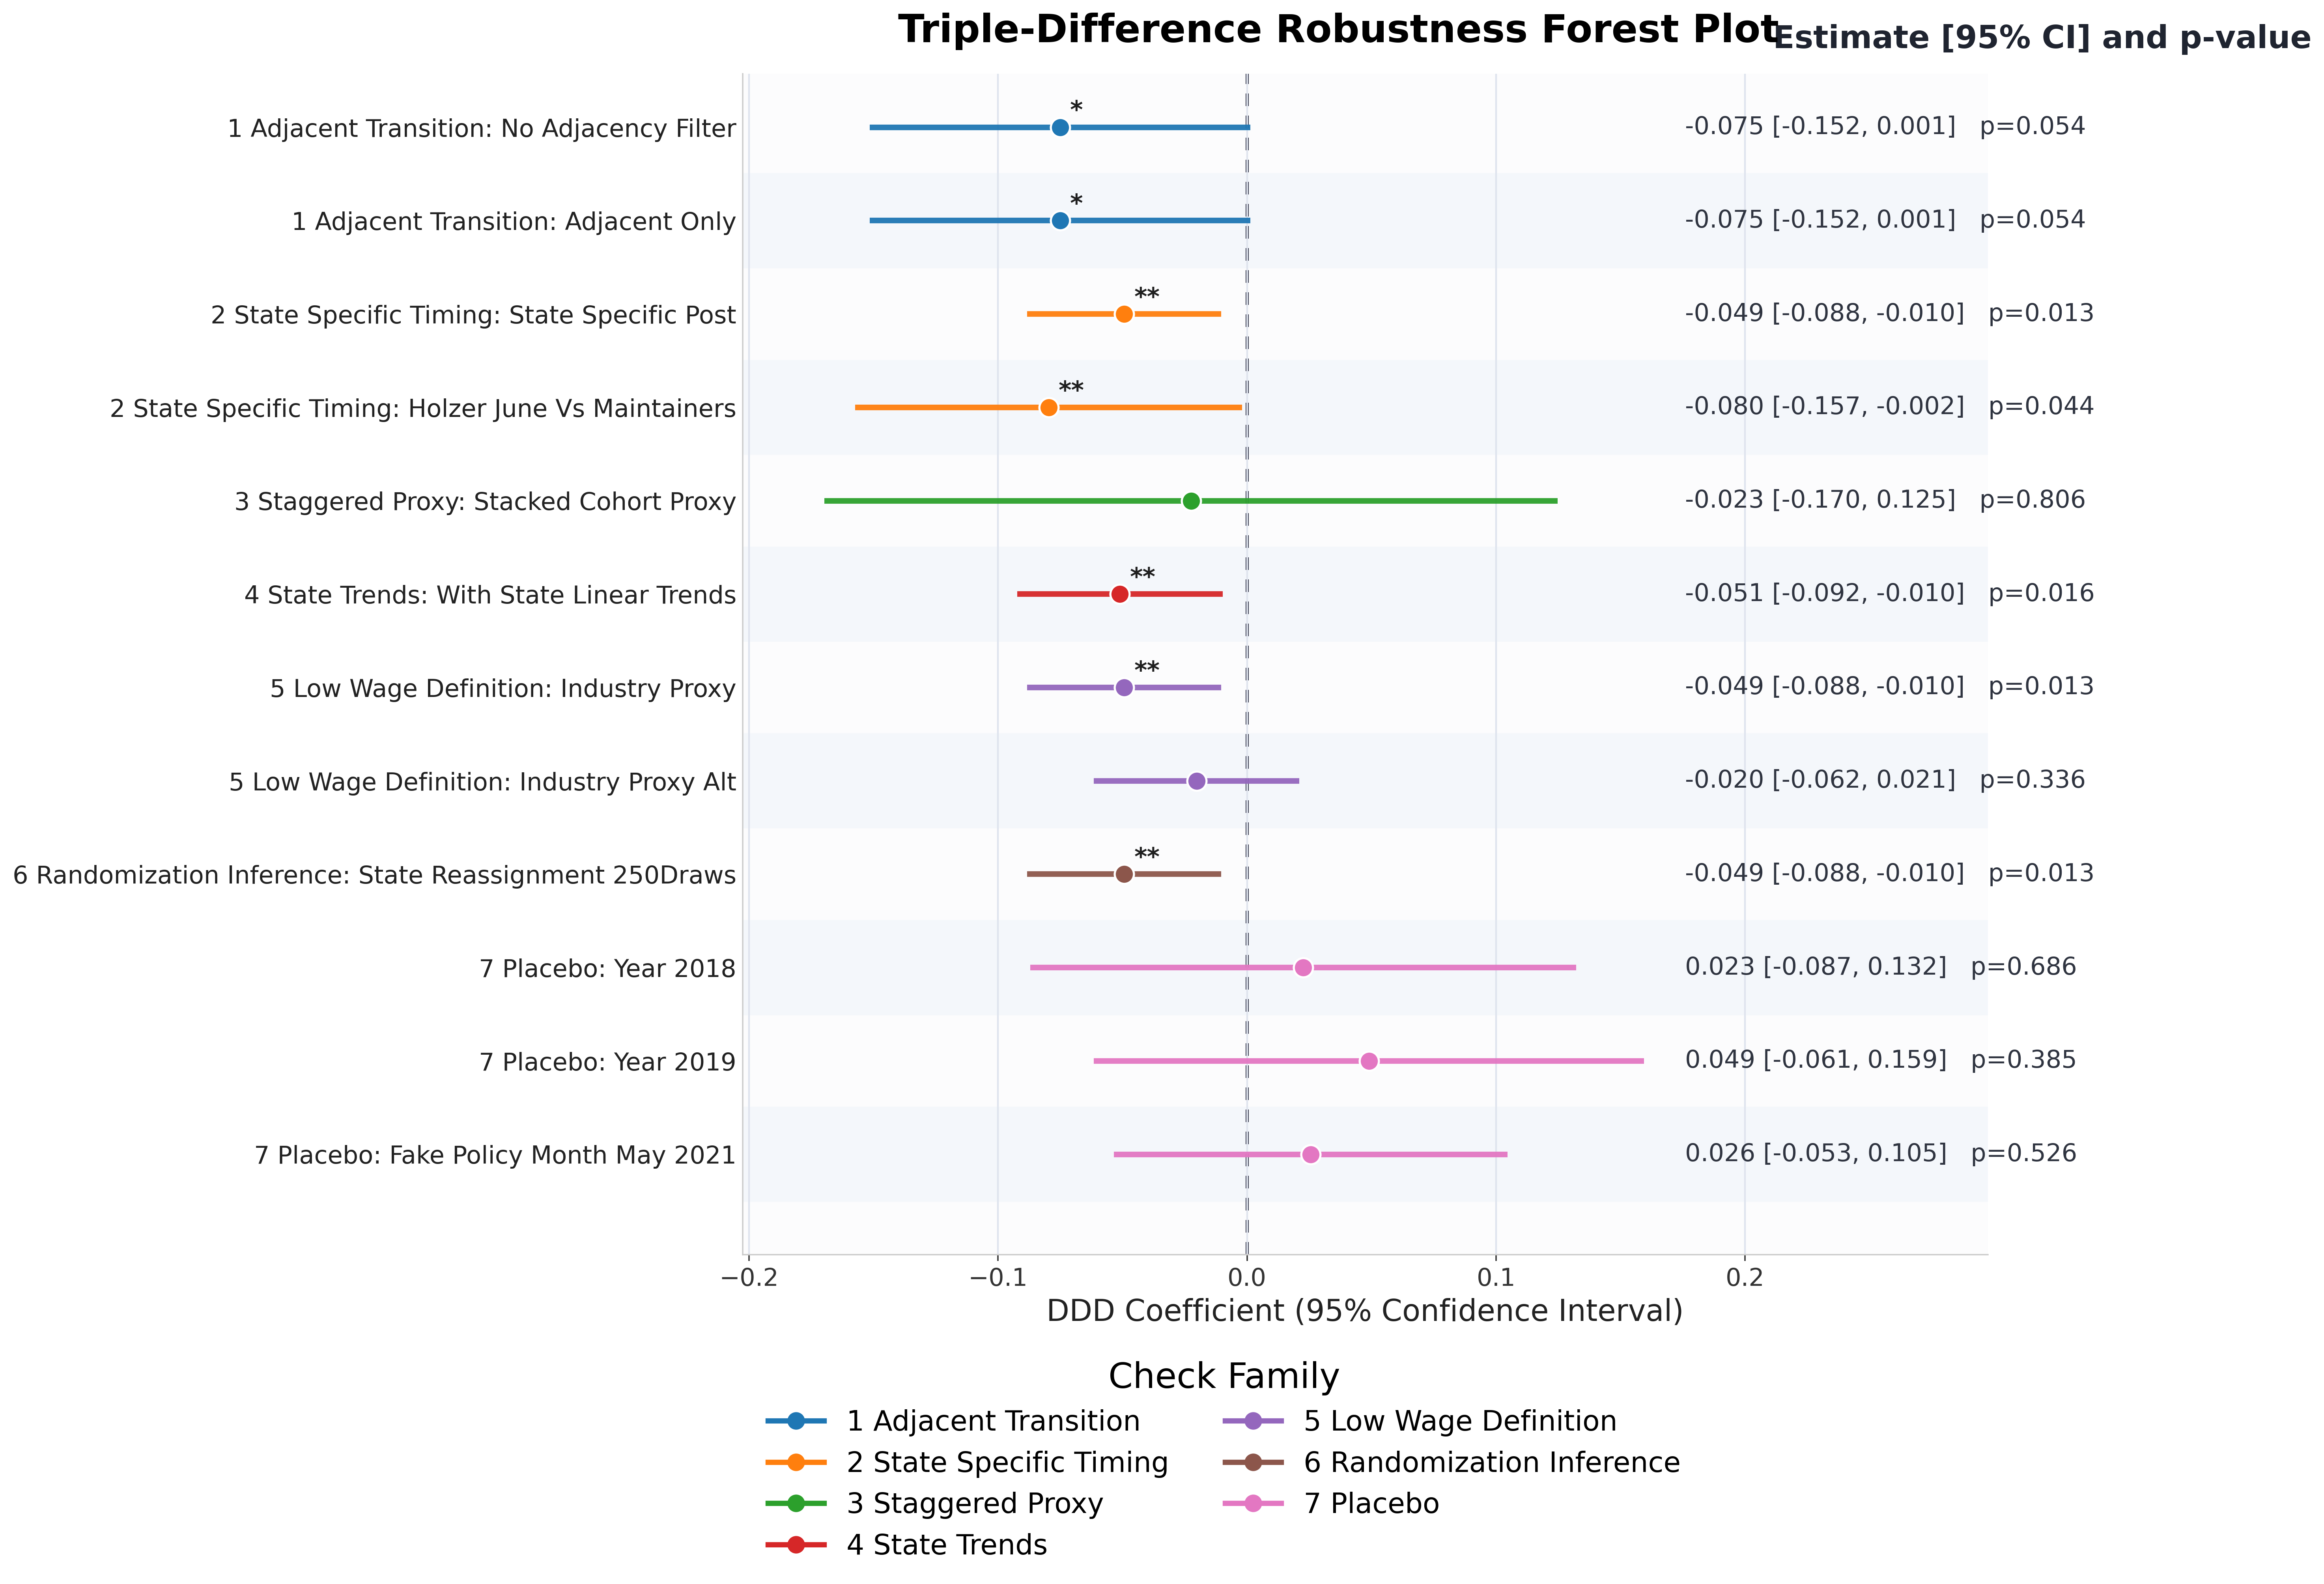

Saved: triple_difference_forest_large_text.png


In [21]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D

# =========================
# 1) Load data
# =========================
df = pd.read_csv("robustness_checks.csv")  # same folder
out_path = "triple_difference_forest_large_text.png"

for c in ["coef", "stderr", "pval", "nobs"]:
    df[c] = pd.to_numeric(df[c], errors="coerce")
df = df.dropna(subset=["coef", "stderr"]).copy()

df["ci_low"] = df["coef"] - 1.96 * df["stderr"]
df["ci_high"] = df["coef"] + 1.96 * df["stderr"]

def clean(s):
    return " ".join(str(s).replace("_", " ").split()).title()

def stars(p):
    if pd.isna(p): return ""
    if p < 0.01: return "***"
    if p < 0.05: return "**"
    if p < 0.10: return "*"
    return ""

df["check_label"] = df["check"].apply(clean)
df["label"] = df.apply(lambda r: f"{clean(r['check'])}: {clean(r['variant'])}", axis=1)
df["stars"] = df["pval"].apply(stars)

df = df.reset_index(drop=True)
y = np.arange(len(df))[::-1]

# =========================
# 2) Colors
# =========================
unique_checks = df["check_label"].unique()
palette = plt.get_cmap("tab10")
check_to_color = {chk: palette(i % palette.N) for i, chk in enumerate(unique_checks)}
df["color"] = df["check_label"].map(check_to_color)

# =========================
# 3) High-quality + larger text
# =========================
plt.rcParams.update({
    "font.family": "DejaVu Sans",
    "font.size": 26,          # base font
    "axes.titlesize": 22,
    "axes.labelsize": 17,
    "xtick.labelsize": 14,
    "ytick.labelsize": 14,
    "legend.fontsize": 16,
    "legend.title_fontsize": 20,
    "figure.facecolor": "white",
    "axes.facecolor": "#fcfcfd",
})

fig_h = max(10, 0.85 * len(df) + 3.2)
fig, ax = plt.subplots(figsize=(18, fig_h), dpi=320)

# Row bands
for yi in y:
    if yi % 2 == 0:
        ax.axhspan(yi - 0.5, yi + 0.5, color="#f4f7fb", zorder=0)

# Forest elements
for i, r in df.iterrows():
    yi = y[i]
    c = r["color"]
    ax.hlines(yi, r["ci_low"], r["ci_high"], color=c, lw=3.2, alpha=0.95, zorder=2)
    ax.scatter(r["coef"], yi, s=120, marker="o", color=c, edgecolor="white", linewidth=1.2, zorder=3)

    if r["stars"]:
        ax.text(r["coef"] + 0.004, yi + 0.10, r["stars"], fontsize=14, weight="bold", color="#1f1f1f")

# Reference line at zero
ax.axvline(0, color="#2b2d42", lw=1.8, ls=(0, (4, 3)), zorder=1)

# Axis labels
ax.set_yticks(y)
ax.set_yticklabels(df["label"])

xmin = min(df["ci_low"].min(), -0.10)
xmax = max(df["ci_high"].max(), 0.08)
span = xmax - xmin
ax.set_xlim(xmin - 0.10 * span, xmax + 0.42 * span)

# Right-side annotation column with large text
x_ann = xmax + 0.05 * span
for i, r in df.iterrows():
    yi = y[i]
    ann = f"{r['coef']:.3f} [{r['ci_low']:.3f}, {r['ci_high']:.3f}]   p={r['pval']:.3f}"
    ax.text(x_ann, yi, ann, fontsize=14, color="#2f3440", va="center")
ax.text(x_ann, y.max() + 0.85, "        Estimate [95% CI] and p-value",
        fontsize=18, weight="bold", color="#1f2430")

# Title + subtitle
ax.set_title("Triple-Difference Robustness Forest Plot    ", weight="bold", pad=18)
ax.text(0, 1.02, "",
        transform=ax.transAxes, fontsize=20, color="#555d6e")
ax.set_xlabel("DDD Coefficient (95% Confidence Interval)")

# Grid/spines
ax.grid(axis="x", color="#dfe4ee", linestyle="-", linewidth=1.0)
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.tick_params(axis="y", length=0)

# Legend
handles = [
    Line2D([0], [0], color=check_to_color[ch], marker='o', lw=3.0, markersize=9, label=ch)
    for ch in unique_checks
]
ax.legend(handles=handles, title="Check Family", frameon=False,
          loc="lower left", bbox_to_anchor=(0.0, -0.28), ncol=2)

plt.tight_layout()
plt.savefig(out_path, bbox_inches="tight", dpi=320)  # high quality export
plt.show()
print("Saved:", out_path)
